In [90]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from itertools import cycle
import plotly.graph_objects as go
import os
import sys

plt.rcParams.update({"figure.dpi": 150})
idx = pd.IndexSlice
pd.options.display.max_columns = None


# LOAD DATA


In [91]:
from util.load_scenarios import load_scenario_df
from util.load_evaluations import load_benchmark_df

eval_df = load_benchmark_df("../data/evaluation/default")
eval_df = eval_df.add_prefix("eval.")


scenario_df = load_scenario_df("../data/definition/routes_devtest_sliced.xml")
scenario_df = scenario_df.add_prefix("def.")

df = eval_df.join(scenario_df, how='inner', validate="1:m")
df = df.droplevel(['fps', 'highquality'])
df.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 1280 entries, ('0', 0) to ('9', 131)
Data columns (total 29 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   eval.route_id                           1280 non-null   object 
 1   eval.status                             1280 non-null   object 
 2   eval.infractions.collisions_layout      1280 non-null   object 
 3   eval.infractions.collisions_pedestrian  1280 non-null   object 
 4   eval.infractions.collisions_vehicle     1280 non-null   object 
 5   eval.infractions.outside_route_lanes    1280 non-null   object 
 6   eval.infractions.red_light              1280 non-null   object 
 7   eval.infractions.route_dev              1280 non-null   object 
 8   eval.infractions.route_timeout          1280 non-null   object 
 9   eval.infractions.stop_infraction        1280 non-null   object 
 10  eval.infractions.vehicle_blocked        1280 no

In [92]:
df.columns

Index(['eval.route_id', 'eval.status', 'eval.infractions.collisions_layout',
       'eval.infractions.collisions_pedestrian',
       'eval.infractions.collisions_vehicle',
       'eval.infractions.outside_route_lanes', 'eval.infractions.red_light',
       'eval.infractions.route_dev', 'eval.infractions.route_timeout',
       'eval.infractions.stop_infraction', 'eval.infractions.vehicle_blocked',
       'eval.duration_game', 'eval.duration_system', 'eval.route_length',
       'eval.score_composed', 'eval.score_penalty', 'eval.score_route',
       'eval.driving_score', 'eval.driving_score_error', 'def.points',
       'def.town', 'def.n_points', 'def.angles', 'def.length', 'def.dist',
       'def.dist_len_ratio', 'def.max_angles', 'def.avg_angles',
       'def.n_turns'],
      dtype='object')

In [93]:
eval_cols = df.columns[df.columns.str.startswith("eval.infractions.")]
df = df[eval_cols]
df = df.drop(columns=['eval.infractions.route_dev'])
df = df.reset_index().set_index(['route_index', 'rep']).sort_index()
df

eval.infractions.collisions_layout  \
route_index rep                                                      
0           0    [Agent collided against object with type=stati...   
            1    [Agent collided against object with type=stati...   
            2    [Agent collided against object with type=stati...   
            3                                                   []   
            4    [Agent collided against object with type=stati...   
...                                                            ...   
131         5                                                   []   
            6                                                   []   
            7                                                   []   
            8                                                   []   
            9                                                   []   

                eval.infractions.collisions_pedestrian  \
route_index rep                                          
0           0                                       []   
            1                                       []   
            2                                       []   
            3                                       []   
            4                                       []   
...                                                ...   
131         5                                       []   
            6                                       []   
            7                                       []   
            8                                       []   
            9                                       []   

                eval.infractions.collisions_vehicle  \
route_index rep                                       
0           0                                    []   
            1                                    []   
            2                                    []   
            3                                    []   
            4                                    []   
...                                             ...   
131         5                                    []   
            6                                    []   
            7                                    []   
            8                                    []   
            9                                    []   

                eval.infractions.outside_route_lanes  \
route_index rep                                        
0           0                                     []   
            1                                     []   
            2                                     []   
            3                                     []   
            4                                     []   
...                                              ...   
131         5                                     []   
            6                                     []   
            7                                     []   
            8                                     []   
            9                                     []   

                eval.infractions.red_light eval.infractions.route_timeout  \
route_index rep                                                             
0           0                           []                             []   
            1                           []                             []   
            2                           []                             []   
            3                           []                             []   
            4                           []                             []   
...                                    ...                            ...   
131         5                           []               [Route timeout.]   
            6                           []               [Route timeout.]   
            7                           []               [Route timeout.]   
            8                           []               [Route timeout.] 

## Flakiness distribution

In [94]:
behaviours_df = df.map(len).map(str).agg(" ".join, axis=1)
behaviours_df.count
behaviours_count = behaviours_df.groupby('route_index').nunique()


In [95]:
behaviours_count = behaviours_count.rename("n_behaviors").to_frame()
behaviours_count['nondeterministic'] = behaviours_count['n_behaviors'] > 1
# behaviours_count['nondeterministic'] = behaviours_count['nondeterministic'].map(str)

behaviours_count

,n_behaviors,nondeterministic
route_index,,
0,2,True
1,2,True
2,2,True
3,1,False
4,2,True
...,...,...
127,1,False
128,1,False
129,1,False


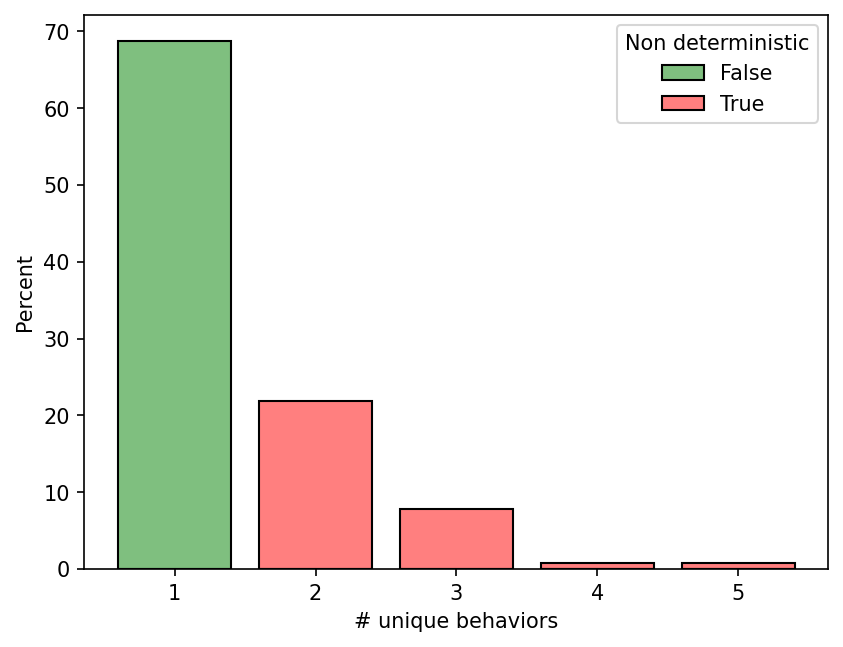

In [96]:


palette = {0: 'green', 1: 'red'}
ax = sns.histplot(
    data=behaviours_count,
    x="n_behaviors",
    hue="nondeterministic",
    stat="percent",
    discrete=True,
    palette= palette,
    shrink=0.8,
    
)
ax.set_xlabel("# unique behaviors")
ax.get_legend().set_title("Non deterministic")

In [97]:
values = behaviours_count['n_behaviors'].value_counts()
values = values.to_frame().transpose()
values.to_numpy().flatten()

array([88, 28, 10,  1,  1])

In [98]:
values = values.reindex(sorted(values.columns), axis=1)
# values['4+'] = values['4'] + values['5'] 
values

n_behaviors,1,2,3,4,5
count,88,28,10,1,1


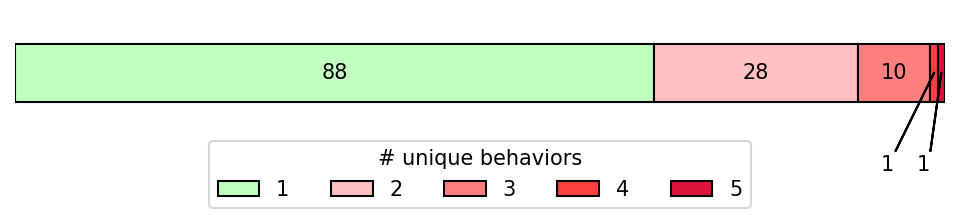

In [99]:
fig, ax = plt.subplots(figsize=(8, 1))
palette = ["#C1FFC1", "#FFC1C1", "#FF7F7F", "#FF4040", "#DC143C"]

ax = values.plot.barh(stacked=True, edgecolor="black", color=palette, ax=ax)
# ax.get_legend().remove()

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 0),
    ncol=len(palette),
    title="# unique behaviors",
)  # Adjust bbox_to_anchor if needed

text_props = dict(
    horizontalalignment="center", verticalalignment="center", color="black"
)
ax.annotate("88", xy=(88 / 2, 0), **text_props)

ax.annotate("28", xy=(88 + (28 / 2), 0), **text_props)

ax.annotate("10", xy=(88 + 28 + (10 / 2), 0), **text_props)

ax.annotate(
    "1",
    xy=(88 + 28 + 10 + 0.5, 0),
    xytext=(120, -0.8),
    **text_props,
    arrowprops=dict(
        facecolor="black",
        width=0,
        headwidth=0,
    ),
)

ax.annotate(
    "1",
    xy=(88 + 28 + 10 + 1.5, 0),
    xytext=(125, -0.8),
    **text_props,
    arrowprops=dict(
        facecolor="black",
        width=0,
        headwidth=0,
    ),
)
ax.set_axis_off()
ax.margins(x=0, y=0)
ax.get_figure().savefig("rq1.pdf", bbox_inches="tight")

## Degree of flakiness

In [100]:
counts = df.map(len)
counts


eval.infractions.collisions_layout  \
route_index rep                                       
0           0                                     1   
            1                                     1   
            2                                     1   
            3                                     0   
            4                                     1   
...                                             ...   
131         5                                     0   
            6                                     0   
            7                                     0   
            8                                     0   
            9                                     0   

                 eval.infractions.collisions_pedestrian  \
route_index rep                                           
0           0                                         0   
            1                                         0   
            2                                         0   
            3                                         0   
            4                                         0   
...                                                 ...   
131         5                                         0   
            6                                         0   
            7                                         0   
            8                                         0   
            9                                         0   

                 eval.infractions.collisions_vehicle  \
route_index rep                                        
0           0                                      0   
            1                                      0   
            2                                      0   
            3                                      0   
            4                                      0   
...                                              ...   
131         5                                      0   
            6                                      0   
            7                                      0   
            8                                      0   
            9                                      0   

                 eval.infractions.outside_route_lanes  \
route_index rep                                         
0           0                                       0   
            1                                       0   
            2                                       0   
            3                                       0   
            4                                       0   
...                                               ...   
131         5                                       0   
            6                                       0   
            7                                       0   
            8                                       0   
            9                                       0   

                 eval.infractions.red_light  eval.infractions.route_timeout  \
route_index rep                                                               
0           0                             0                               0   
            1                             0                               0   
            2                             0                               0   
            3                             0                               0   
            4                             0                               0   
...                                     ...                             ...   
131         5                             0                               1   
            6                             0                               1   
            7                             0                               1   
            8                             0                               1   
            9                             0                               1   

                 eval.infractions.

In [101]:
stds = counts.groupby('route_index').std()
stds = stds.rename(columns=lambda x: x.removeprefix("eval.infractions."))
stds = stds.rename(columns=lambda x: x.capitalize().replace("_", " "))

In [102]:
flaky_mask = behaviours_count['nondeterministic']

In [103]:
stds

,Collisions layout,Collisions pedestrian,Collisions vehicle,Outside route lanes,Red light,Route timeout,Stop infraction,Vehicle blocked
route_index,,,,,,,,
0,0.316228,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
1,0.000000,0.0,0.000000,0.0,0.0,0.516398,0.0,0.0
2,0.000000,0.0,0.000000,0.0,0.0,0.316228,0.0,0.0
3,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
4,0.000000,0.0,0.000000,0.0,0.0,0.316228,0.0,0.0
...,...,...,...,...,...,...,...,...
127,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
128,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
129,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0


### All scenarios

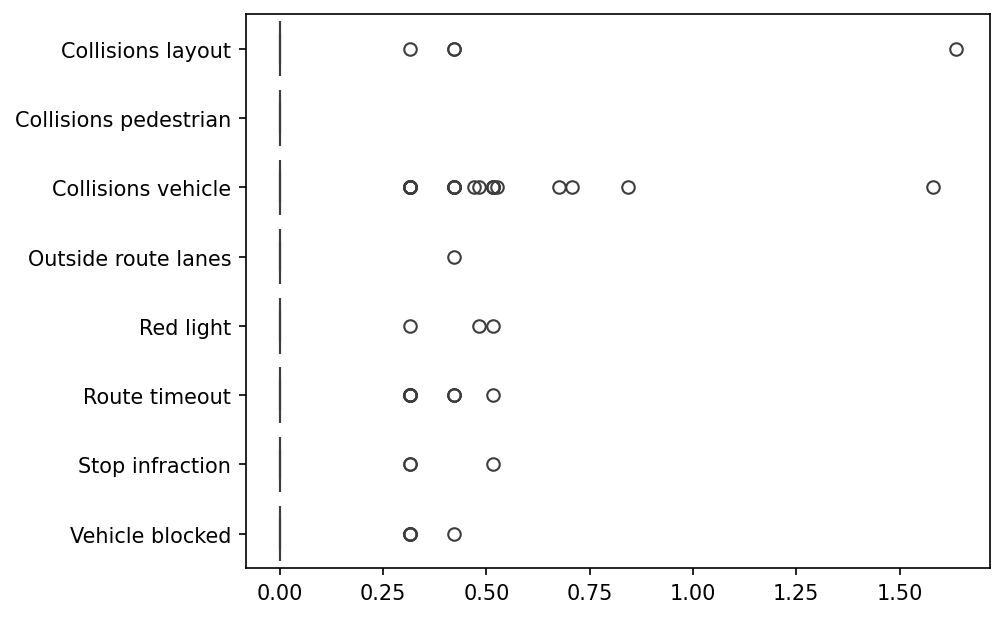

In [104]:

ax = sns.boxplot(data=stds, orient="h")

### Only flaky

In [105]:
stds = stds[['Collisions layout',
 'Collisions pedestrian',
 'Collisions vehicle',
 'Outside route lanes',
 'Red light',
 'Stop infraction',
 'Vehicle blocked',
 'Route timeout',
 ]]

In [106]:
old_names = stds.columns.to_list()
old_names

['Collisions layout',
 'Collisions pedestrian',
 'Collisions vehicle',
 'Outside route lanes',
 'Red light',
 'Stop infraction',
 'Vehicle blocked',
 'Route timeout']

In [107]:
new_names = [
    "Collisions with static objects",
    "Collisions with pedestrians",
    "Collisions with vehicles",
    "Out-of-lane episodes",
    "Running a red light",
    "Running stop sign",
    "Vehicle-blocked episodes",
    "Route time-out",
]

stds = stds.rename(columns=dict(zip(old_names, new_names)))

In [108]:

stds = stds[new_names]
stds = stds[flaky_mask]

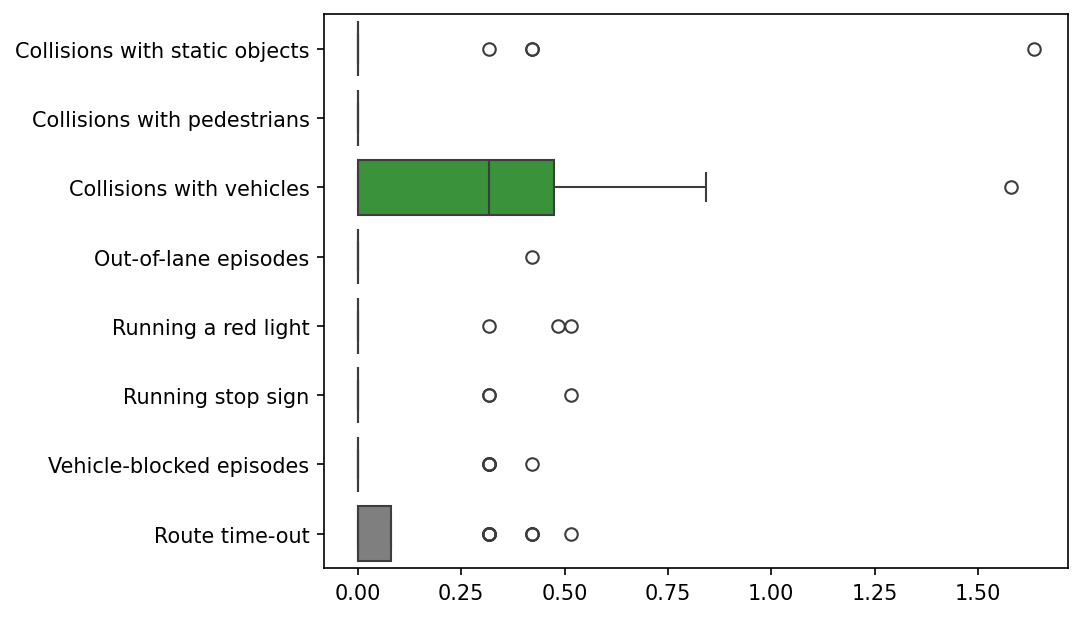

In [109]:

ax = sns.boxplot(data=stds, orient="h")
ax.get_figure().savefig("rq2.pdf", bbox_inches="tight")

### Stats

In [110]:
stats = stds.describe().transpose()
stats = stats[['mean', 'min', 'max']]
stats

,mean,min,max
Collisions with static objects,0.069897,0.0,1.636392
Collisions with pedestrians,0.000000,0.0,0.000000
Collisions with vehicles,0.299789,0.0,1.581139
Out-of-lane episodes,0.010541,0.0,0.421637
Running a red light,0.032892,0.0,0.516398
Running stop sign,0.028721,0.0,0.516398
Vehicle-blocked episodes,0.042164,0.0,0.421637
Route time-out,0.091967,0.0,0.516398


In [111]:
print(stats.to_latex(float_format="%.2f"))

\begin{tabular}{lrrr}
\toprule
 & mean & min & max \\
\midrule
Collisions with static objects & 0.07 & 0.00 & 1.64 \\
Collisions with pedestrians & 0.00 & 0.00 & 0.00 \\
Collisions with vehicles & 0.30 & 0.00 & 1.58 \\
Out-of-lane episodes & 0.01 & 0.00 & 0.42 \\
Running a red light & 0.03 & 0.00 & 0.52 \\
Running stop sign & 0.03 & 0.00 & 0.52 \\
Vehicle-blocked episodes & 0.04 & 0.00 & 0.42 \\
Route time-out & 0.09 & 0.00 & 0.52 \\
\bottomrule
\end{tabular}



## Manual inspection

In [112]:
most_flaky = behaviours_count[behaviours_count['n_behaviors'] > 2]
most_flaky['n_behaviors'].sort_values()

route_index
6      3
16     3
19     3
29     3
48     3
65     3
73     3
89     3
95     3
130    3
61     4
8      5
Name: n_behaviors, dtype: int64

In [113]:
def drop_boring_columns(df):
    # if a column has one elements its boring lets drop it
    for series_name, series in df.items():
        if len(series.unique()) == 1:
            df = df.drop(series_name, axis=1)
            print(f"Dropped: {series_name}")

    return df

In [114]:
most_flaky_df = df.loc[most_flaky.index].map(len)


drop_boring_columns(most_flaky_df.loc[8])

Dropped: eval.infractions.collisions_pedestrian
Dropped: eval.infractions.collisions_vehicle
Dropped: eval.infractions.outside_route_lanes
Dropped: eval.infractions.red_light
Dropped: eval.infractions.route_timeout
Dropped: eval.infractions.stop_infraction
Dropped: eval.infractions.vehicle_blocked


,eval.infractions.collisions_layout
rep,
0,3
1,2
2,0
3,1
4,1
5,0
6,5
7,0
8,1
